# Calidad de los predictores y VIF inicial

Dueño: Julián. Solo análisis y figuras: la lógica reutilizable va en `src/`.
Antes de cada commit: Kernel → Restart & Run All.

**Regla de este notebook:** los datos entran solo con `cargar_entrenamiento` (febrero de 2019 a
julio de 2025). La prueba (agosto de 2025 a julio de 2026) no se toca.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import PREDICTORES_NUM, PREDICTORES_REZ1, RUTA_TABLAS
from src.datos.cargar import cargar_entrenamiento
from src.evaluacion.interpretacion import calcular_vif
from src.figuras import aplicar_estilo, guardar_figura

aplicar_estilo()
RUTA_TABLAS.mkdir(parents=True, exist_ok=True)

## 0. Los datos y su estructura

Los predictores son iguales en los tres escenarios (solo cambia el objetivo), así que se usa el
central. Antes de describirlos hay que entender **cuántos valores distintos tiene cada uno**,
porque el panel repite las mismas cifras muchas veces:

- `icc`, `inflacion_anual`, `tasa_consumo` e `importaciones_muebles_usd_miles` son **nacionales**:
  un valor por mes, repetido en las 56 filas de ese mes (7 dominios × 8 líneas).
- `area_vivienda_m2` es la única que cambia por **departamento**: un valor por mes y dominio,
  repetido en las 8 líneas.

In [2]:
df = cargar_entrenamiento("central")
print(f"Filas: {len(df):,} | meses: {df['fecha'].nunique()} | "
      f"{df['fecha'].min():%Y-%m} a {df['fecha'].max():%Y-%m}")

# Unidad real de observación de cada predictor
mensual = df.drop_duplicates("fecha").set_index("fecha")       # 1 fila por mes
dep_mes = df.drop_duplicates(["fecha", "departamento"])        # 1 fila por mes y dominio
print(f"Observaciones distintas: nacionales = {len(mensual)}, vivienda = {len(dep_mes)}")

# Comprobación: los 4 nacionales no cambian dentro de un mes; la vivienda solo cambia por dominio
nacionales = [c for c in PREDICTORES_NUM if c != "area_vivienda_m2"]
assert df.groupby("fecha")[nacionales].nunique().max().max() == 1
assert df.groupby(["fecha", "departamento"])["area_vivienda_m2"].nunique().max() == 1

Filas: 4,368 | meses: 78 | 2019-02 a 2025-07
Observaciones distintas: nacionales = 78, vivienda = 546


## 1. Tabla descriptiva de los 10 predictores

Cada predictor se describe en su unidad real de observación (78 meses los nacionales, 546
combinaciones mes × dominio la vivienda); si se usaran las 4.368 filas, cada mes pesaría 56 veces y
el `count` engañaría. Las 5 columnas `_rez1` son las mismas series corridas un mes, y son las que
entran al modelo (`USAR_REZAGO = True`).

In [3]:
def unidad(columna):
    return dep_mes[columna] if columna.startswith("area_vivienda") else mensual[columna]


filas = {}
for columna in PREDICTORES_NUM + PREDICTORES_REZ1:
    s = unidad(columna)
    filas[columna] = {
        "n": s.count(),
        "media": s.mean(),
        "desv_tipica": s.std(),
        "minimo": s.min(),
        "mediana": s.median(),
        "maximo": s.max(),
        "asimetria": s.skew(),
    }
descriptiva = pd.DataFrame(filas).T
descriptiva.index.name = "predictor"
descriptiva.to_csv(RUTA_TABLAS / "descriptiva_predictores.csv", float_format="%.4f")
descriptiva.round(2)

,n,media,desv_tipica,minimo,mediana,maximo,asimetria
predictor,,,,,,,
icc,78.0,-14.00,9.89,-41.30,-12.85,5.30,-0.52
inflacion_anual,78.0,6.28,3.61,1.49,5.20,13.34,0.58
tasa_consumo,78.0,20.60,4.13,16.52,19.06,31.39,1.33
importaciones_muebles_usd_miles,78.0,34255.94,7731.89,15069.83,33981.51,53701.37,0.12
area_vivienda_m2,546.0,232648.73,197323.19,6492.00,174441.50,1112245.00,1.57
icc_rez1,78.0,-14.11,9.73,-41.30,-12.85,2.90,-0.60
inflacion_anual_rez1,78.0,6.25,3.63,1.49,5.20,13.34,0.58
tasa_consumo_rez1,78.0,20.64,4.10,16.59,19.08,31.39,1.34
importaciones_muebles_usd_miles_rez1,78.0,34075.69,7534.34,15069.83,33981.51,53701.37,0.09


**Lectura.** `area_vivienda_m2` (área licenciada para vivienda) es la que más se aparta de una
distribución simétrica: su asimetría es la más alta (1,58) y su máximo (≈ 1,1 millones de m²) está
muy lejos de la mediana (≈ 173 mil), porque mezcla dominios muy distintos en tamaño.
`tasa_consumo` también tiene cola derecha (1,34). `importaciones_muebles_usd_miles` es casi
simétrica (0,09). `icc` toma valores negativos (hasta −41,3), lo que descarta cualquier
transformación logarítmica.

## 2. Matriz de correlación

Con filas repetidas de forma uniforme (cada mes 56 veces, cada mes × dominio 8 veces), la
correlación calculada sobre el panel es igual a la calculada sobre las observaciones distintas;
por eso se puede usar `df.corr()` directo.

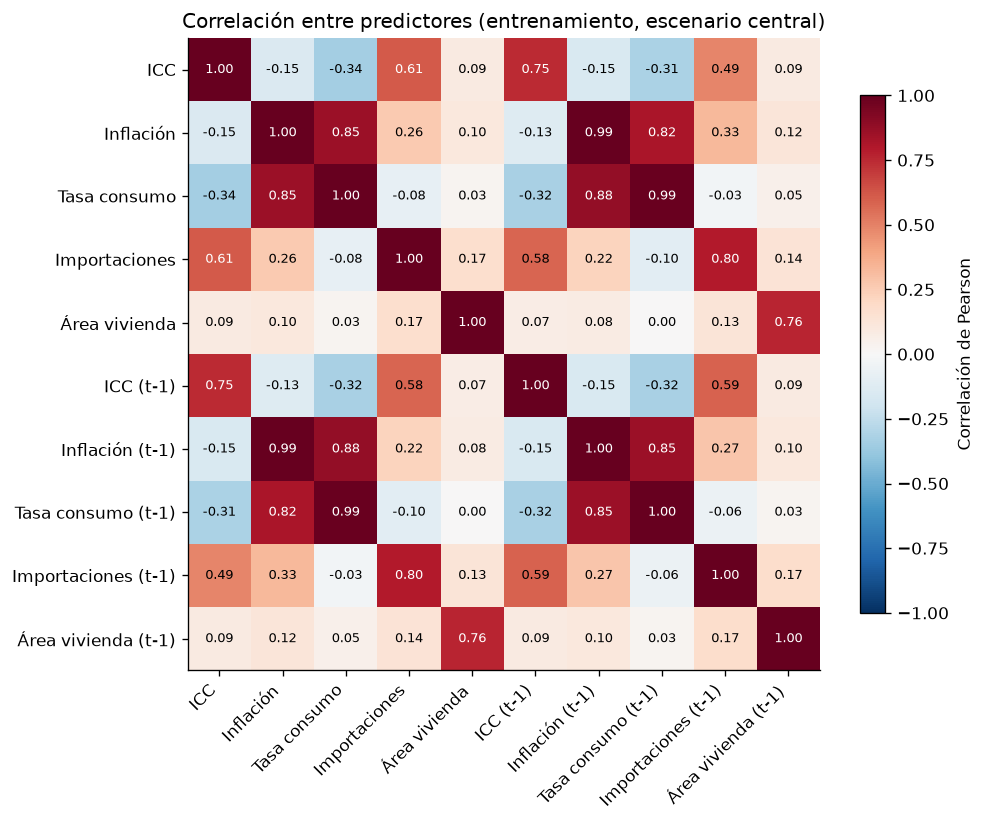

Inflación (t-1)      Tasa consumo (t-1)     0.85
ICC (t-1)            Importaciones (t-1)    0.59
                     Tasa consumo (t-1)    -0.32
Inflación (t-1)      Importaciones (t-1)    0.27
Importaciones (t-1)  Área vivienda (t-1)    0.17
ICC (t-1)            Inflación (t-1)       -0.15
Inflación (t-1)      Área vivienda (t-1)    0.10
ICC (t-1)            Área vivienda (t-1)    0.09
Tasa consumo (t-1)   Importaciones (t-1)   -0.06
                     Área vivienda (t-1)    0.03
ICC (t-1)            ICC (t-1)               NaN
Inflación (t-1)      ICC (t-1)               NaN
                     Inflación (t-1)         NaN
Tasa consumo (t-1)   ICC (t-1)               NaN
                     Inflación (t-1)         NaN
                     Tasa consumo (t-1)      NaN
Importaciones (t-1)  ICC (t-1)               NaN
                     Inflación (t-1)         NaN
                     Tasa consumo (t-1)      NaN
                     Importaciones (t-1)     NaN
Área vivienda (t-1) 

In [4]:
etiquetas = {
    "icc": "ICC",
    "inflacion_anual": "Inflación",
    "tasa_consumo": "Tasa consumo",
    "importaciones_muebles_usd_miles": "Importaciones",
    "area_vivienda_m2": "Área vivienda",
}
nombres = [etiquetas[c] for c in PREDICTORES_NUM] + [
    etiquetas[c] + " (t-1)" for c in PREDICTORES_NUM
]
corr = df[PREDICTORES_NUM + PREDICTORES_REZ1].corr()
corr.index = corr.columns = nombres

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(nombres)), nombres, rotation=45, ha="right")
ax.set_yticks(range(len(nombres)), nombres)
ax.grid(False)
for i in range(len(nombres)):
    for j in range(len(nombres)):
        color = "white" if abs(corr.iloc[i, j]) > 0.6 else "black"
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color=color)
ax.set_title("Correlación entre predictores (entrenamiento, escenario central)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlación de Pearson")
guardar_figura(fig, "calidad_matriz_correlacion")
plt.show()

# Pares de los 5 rezagados, de mayor a menor correlación absoluta
rez = corr.loc[nombres[5:], nombres[5:]]
pares = rez.where(np.triu(np.ones(rez.shape, dtype=bool), k=1)).stack()
pares.reindex(pares.abs().sort_values(ascending=False).index).round(2)

**Lectura.** Cada predictor se correlaciona con su propio rezago entre 0,75 (ICC) y 0,99
(inflación y tasa de consumo), lo esperable en series mensuales. Entre predictores distintos, la
pareja más correlacionada es **inflación–tasa de consumo (0,85)**; le sigue ICC–importaciones
(0,59). El área de vivienda no pasa de 0,17 con ninguno, porque es la única que varía por dominio.

### Por qué importa el 0,85

Una correlación alta entre dos predictores es justo lo que produce multicolinealidad: el modelo no
puede separar el efecto de uno del efecto del otro. El VIF (sección 4) lo cuantifica.

## 3. Cada serie en el tiempo, con los meses de `covid` sombreados

Se grafican las series del mismo mes (las `_rez1` son las mismas corridas un mes). El área de
vivienda se muestra sumando los 7 dominios, solo para poder verla como una línea nacional; en el
modelo entra por dominio.

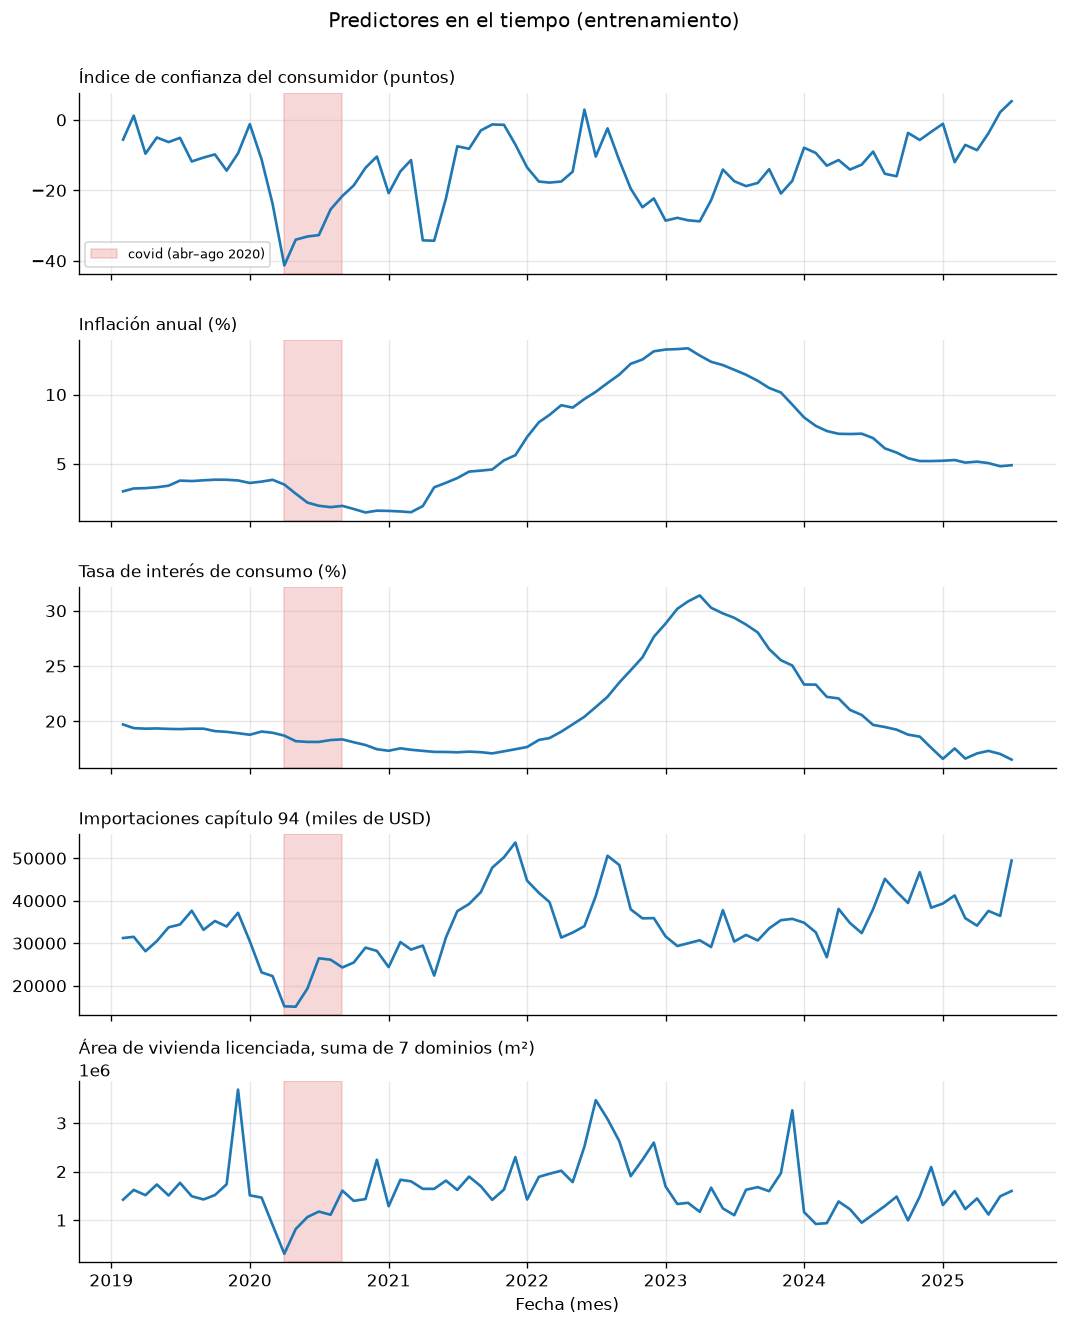

In [5]:
covid_ini = df.loc[df["covid"] == 1, "fecha"].min()
covid_fin = df.loc[df["covid"] == 1, "fecha"].max() + pd.offsets.MonthBegin(1)  # fin del último mes

series = {c: mensual[c] for c in nacionales}
series["area_vivienda_m2"] = dep_mes.groupby("fecha")["area_vivienda_m2"].sum()
titulos = {
    "icc": "Índice de confianza del consumidor (puntos)",
    "inflacion_anual": "Inflación anual (%)",
    "tasa_consumo": "Tasa de interés de consumo (%)",
    "importaciones_muebles_usd_miles": "Importaciones capítulo 94 (miles de USD)",
    "area_vivienda_m2": "Área de vivienda licenciada, suma de 7 dominios (m²)",
}

fig, ejes = plt.subplots(len(series), 1, figsize=(9, 11), sharex=True)
for ax, (columna, serie) in zip(ejes, series.items()):
    ax.plot(serie.index, serie.values, color="tab:blue", lw=1.6)
    ax.axvspan(covid_ini, covid_fin, color="tab:red", alpha=0.18, label="covid (abr–ago 2020)")
    ax.set_title(titulos[columna], loc="left", fontsize=10)
ejes[0].legend(loc="lower left", fontsize=8)
ejes[-1].set_xlabel("Fecha (mes)")
fig.suptitle("Predictores en el tiempo (entrenamiento)", y=1.0)
fig.tight_layout()
guardar_figura(fig, "calidad_series_predictores")
plt.show()

**Lectura.** El confinamiento de 2020 deja huella clara en tres series: el ICC cae a su mínimo
(−41,3) en abril, las importaciones tocan su mínimo (≈ 15.000 miles de USD) en abril–mayo y el área
de vivienda licenciada se desploma en abril (≈ 0,31 millones de m², frente a una media mensual
≈ 1,6 millones). La tasa de consumo casi no reacciona (de 19,1 % en febrero a 18,1 % en junio).
La inflación llega a su mínimo en noviembre de 2020 (1,5 %) y después sube hasta su máximo en marzo
de 2023 (13,3 %). El área de vivienda tiene además un pico fuerte cada diciembre (promedio ≈ 2,7
millones de m², contra 1,35–1,75 millones en los demás meses): una estacionalidad que el modelo
captura con las variables de mes.

## 4. VIF inicial de los 5 predictores rezagados

El VIF mide cuánto se infla la varianza de un coeficiente porque el predictor se parece a los
otros. Se calcula sobre los 5 predictores numéricos que entran al modelo, en el panel completo (la
matriz de diseño real). Como comparación, se repite con las observaciones distintas (78 meses, vivienda
sumada) para ver si repetir filas cambia la conclusión.

In [6]:
vif = calcular_vif(df, PREDICTORES_REZ1)

# Comparación: una fila por mes (78), vivienda sumada de los 7 dominios
vista_mensual = mensual[[c for c in PREDICTORES_REZ1 if not c.startswith("area_")]].copy()
vista_mensual["area_vivienda_m2_rez1"] = df.groupby("fecha")["area_vivienda_m2_rez1"].sum()
vif["vif_vista_mensual"] = calcular_vif(vista_mensual, PREDICTORES_REZ1)["vif"].to_numpy()

vif.to_csv(RUTA_TABLAS / "vif_inicial.csv", index=False, float_format="%.4f")
vif.round(2)

,variable,vif,vif_vista_mensual
0,icc_rez1,1.83,1.83
1,inflacion_anual_rez1,6.28,6.40
2,tasa_consumo_rez1,5.60,5.64
3,importaciones_muebles_usd_miles_rez1,2.51,2.61
4,area_vivienda_m2_rez1,1.04,1.25


**Lectura.** Ningún VIF llega a 10. Los más altos son la inflación (≈ 6,3) y la tasa de consumo
(≈ 5,6): son justo la pareja con correlación 0,85 de la sección 2 (ambas subieron hasta 2023), así
que su multicolinealidad es moderada y se explica entre ellas. El resto está por debajo de 3.
Frente al artículo base (VIF de 16,16 y 23,18) la multicolinealidad bajó mucho; es consecuencia de
haber excluido población y el índice de precios al productor. Repetir filas no cambia la
conclusión: la vista mensual da prácticamente lo mismo.

## 5. Evidencia para proponer transformaciones

Se mide la asimetría de cada predictor antes y después de aplicar logaritmo (solo si todos sus
valores son positivos). Es la base de las propuestas de `docs/diccionario_datos.md`.

In [7]:
candidatos = {}
for columna in PREDICTORES_REZ1:
    s = unidad(columna)
    candidatos[columna] = {
        "asimetria_original": s.skew(),
        "asimetria_log": np.log(s).skew() if (s > 0).all() else np.nan,
        "minimo": s.min(),
    }
asimetria = pd.DataFrame(candidatos).T
asimetria.index.name = "predictor"
asimetria["log_mejora"] = asimetria["asimetria_log"].abs() < asimetria["asimetria_original"].abs()
asimetria.to_csv(RUTA_TABLAS / "asimetria_transformaciones.csv", float_format="%.4f")
asimetria.round(2)

,asimetria_original,asimetria_log,minimo,log_mejora
predictor,,,,
icc_rez1,-0.60,NaN,-41.30,False
inflacion_anual_rez1,0.58,-0.26,1.49,True
tasa_consumo_rez1,1.34,1.14,16.59,True
importaciones_muebles_usd_miles_rez1,0.09,-0.88,15069.83,False
area_vivienda_m2_rez1,1.58,-0.54,6492.00,True


**Lectura.** El logaritmo solo corrige de verdad la asimetría del área de vivienda (de 1,58 a
−0,54). En importaciones la empeora (de 0,09 a −0,88: la serie ya era casi simétrica), en tasa de
consumo la deja por encima de 1 (de 1,34 a 1,14), y en ICC no se puede aplicar porque hay valores
negativos. La inflación mejora algo (de 0,58 a −0,26), pero es un porcentaje y su asimetría original
ya era moderada.